# Lab 4: Adiabatic Quantum Computing and a First Look at Quantum Gates

**Course:** Quantum Optimization Lab (QCL7350)

**Topics covered:** Quantum gates and Bloch sphere warm-up, Hamiltonians $H_M$ and $H_P$, the adiabatic theorem in action, Trotterization, solving SAT with quantum annealing style QUBOs

**Tools:** qiskit, qiskit-aer, numpy, scipy, dimod, dwave-neal, matplotlib

**Session length:** 40-45 minutes, live walkthrough with in-class checkpoints

**Builds on:** Lecture 8 (Quantum Mechanics Review) and Lecture 9 (Adiabatic Quantum Computing)

## Learning objectives

By the end of this lab you should be able to:

1. Build single and two qubit circuits in Qiskit, read a circuit diagram, and read a Bloch sphere plot.
2. State the adiabatic theorem in your own words and explain why a slow evolution keeps a system in its ground state.
3. Build the mixer Hamiltonian $H_M$ and a problem Hamiltonian $H_P$ for a small example, and simulate $H(t) = (1-s(t))H_M + s(t)H_P$ evolving over time.
4. Compare a linear annealing schedule against a quadratic one and explain the difference in the final success probability.
5. Explain Trotterization in one sentence and recognize it as the bridge between the adiabatic algorithm and QAOA.
6. Formulate 2-SAT and 3-SAT as a QUBO and solve it with a classical stand-in for a quantum annealer.

Why this order? Today's gates and Bloch sphere section is not a detour, it is the exact vocabulary the next lab (QAOA, VQE, VQC) will assume you already have.


In [1]:
!pip install qiskit qiskit-aer dimod dwave-neal numpy scipy matplotlib -q

In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, eigh

import dimod
import neal

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector

RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)
sampler = neal.SimulatedAnnealingSampler()

print("dimod version:", dimod.__version__)
print("neal version:", neal.__version__)

import qiskit
print("qiskit version:", qiskit.__version__)

dimod version: 0.12.22
neal version: 0.6.0
qiskit version: 2.3.0


---
# Part 1: Quantum gates and the Bloch sphere

Every algorithm you will build for the rest of the course, QAOA, VQE, VQC, is a circuit made of a handful of gates repeated many times. Today we just meet the gates and watch what they do to a single qubit, using the Bloch sphere from Lecture 8 as our picture.

Recall: $|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$ is a point on the surface of the Bloch sphere. Gates are rotations of that point.

## Single-qubit gates

| Gate | Matrix | Effect |
|---|---|---|
| $X$ | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | bit flip, $\lvert 0\rangle \leftrightarrow \lvert 1\rangle$ |
| $H$ | $\tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | creates superposition, $\lvert 0\rangle \to \lvert+\rangle$ |
| $R_X(\theta)$ | $e^{-i\theta\sigma_x/2}$ | rotation about the x-axis of the Bloch sphere |
| $R_Y(\theta)$ | $e^{-i\theta\sigma_y/2}$ | rotation about the y-axis |
| $R_Z(\theta)$ | $e^{-i\theta\sigma_z/2}$ | rotation about the z-axis, a phase gate |

$R_X$, $R_Y$, and $R_Z$ are the gates QAOA and VQE build their circuits out of, so it is worth building intuition for them now.

## Two-qubit gates

A single-qubit gate can never create entanglement, since it only ever touches one qubit's own state. Entanglement, which Lecture 8 introduced, needs a gate that acts on two qubits at once.

| Gate | Effect |
|---|---|
| CNOT | flips the target qubit if and only if the control qubit is $\lvert1\rangle$ |
| $R_{ZZ}(\theta)$ | $e^{-i\theta \sigma_z^{(i)}\sigma_z^{(j)}/2}$, a phase that depends on whether the two qubits agree or disagree in the $z$ basis |

$R_{ZZ}$ is exactly the gate that implements an Ising interaction term $J_{ij}\sigma_z^{(i)}\sigma_z^{(j)}$ on real hardware, which is precisely the kind of term that shows up in every $H_P$ we build from a QUBO, as you saw in Lecture 8's slide on problem Hamiltonian construction.

## 1.1 The starting state $|0\rangle$

The qubit always starts at the north pole of the Bloch sphere.


Statevector: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


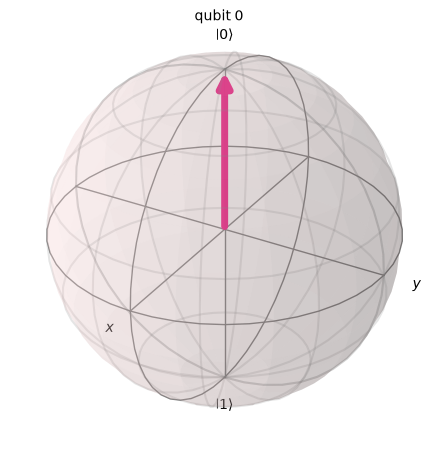

In [3]:
qc0 = QuantumCircuit(1)
state0 = Statevector.from_instruction(qc0)
print("Statevector:", state0)
plot_bloch_multivector(state0)

## 1.2 The Hadamard gate: from a basis state to a superposition

$H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = |+\rangle$. On the Bloch sphere this is a rotation from the north pole out to the equator.


   ┌───┐
q: ┤ H ├
   └───┘
Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


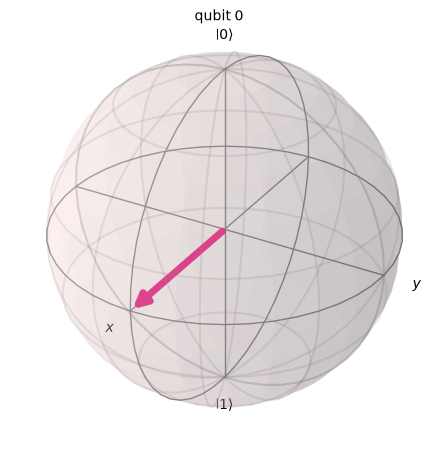

In [4]:
qc_h = QuantumCircuit(1)
qc_h.h(0)
print(qc_h.draw())

state_h = Statevector.from_instruction(qc_h)
print("Statevector:", state_h)
plot_bloch_multivector(state_h)

## 1.3 Rotation gates: dialing in any point on the sphere

$R_x(\theta)$, $R_y(\theta)$, $R_z(\theta)$ rotate the Bloch vector about the x, y, z axis by angle $\theta$. These are the knobs that a variational circuit (QAOA, VQE, VQC, coming up in the next lab) actually trains.


   ┌─────────┐
q: ┤ Rx(π/2) ├
   └─────────┘
Statevector: Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


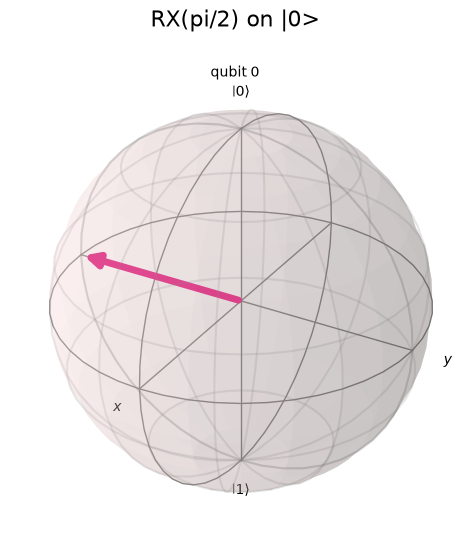

In [5]:
theta = np.pi / 2

# RX on |0>: tips the vector from the north pole down toward the y-axis
qc_rx = QuantumCircuit(1)
qc_rx.rx(theta, 0)
state_rx = Statevector.from_instruction(qc_rx)
print(qc_rx.draw())
print("Statevector:", state_rx)
plot_bloch_multivector(state_rx, title="RX(pi/2) on |0>")

   ┌─────────┐
q: ┤ Ry(π/2) ├
   └─────────┘
Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


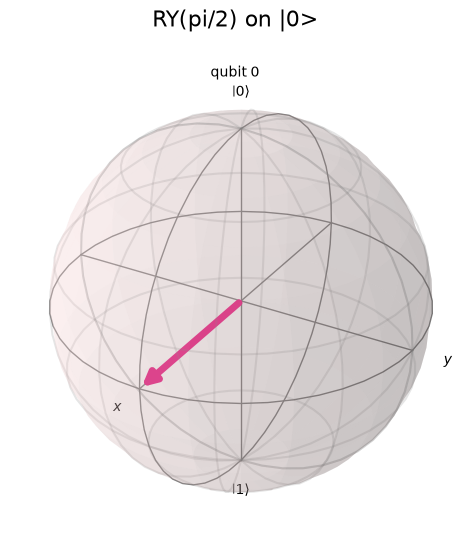

In [6]:
# RY on |0>: tips the vector from the north pole down toward the x-axis
qc_ry = QuantumCircuit(1)
qc_ry.ry(theta, 0)
state_ry = Statevector.from_instruction(qc_ry)
print(qc_ry.draw())
print("Statevector:", state_ry)
plot_bloch_multivector(state_ry, title="RY(pi/2) on |0>")

   ┌───┐┌─────────┐
q: ┤ H ├┤ Rz(π/2) ├
   └───┘└─────────┘
Statevector: Statevector([0.5-0.5j, 0.5+0.5j],
            dims=(2,))


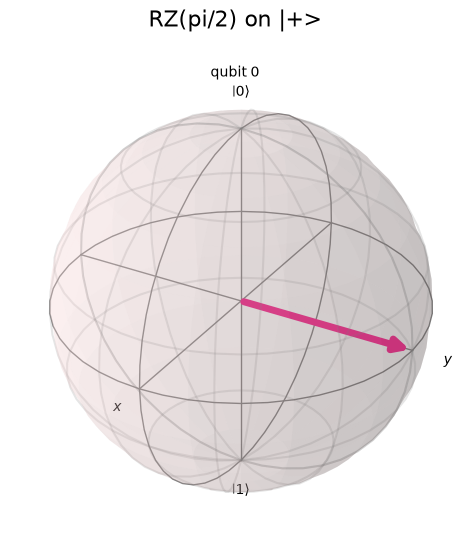

In [7]:
# RZ on |0> would be invisible on the Bloch sphere, since |0> is already
# a Z eigenstate, so we start from |+> instead and watch RZ spin it
# from the +x direction toward the +y direction
qc_rz = QuantumCircuit(1)
qc_rz.h(0)
qc_rz.rz(theta, 0)
state_rz = Statevector.from_instruction(qc_rz)
print(qc_rz.draw())
print("Statevector:", state_rz)
plot_bloch_multivector(state_rz, title="RZ(pi/2) on |+>")

## 1.4 A two qubit gate: CNOT and entanglement

A single qubit gate can never create entanglement, no matter how you rotate it. You need at least one two qubit gate. CNOT flips the target qubit only if the control qubit is $|1\rangle$. Starting from $|+\rangle|0\rangle$ and applying CNOT gives the Bell state $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ from Lecture 8.


     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
Statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Is this a product state? No, this is the maximally entangled Bell state from Lecture 8.


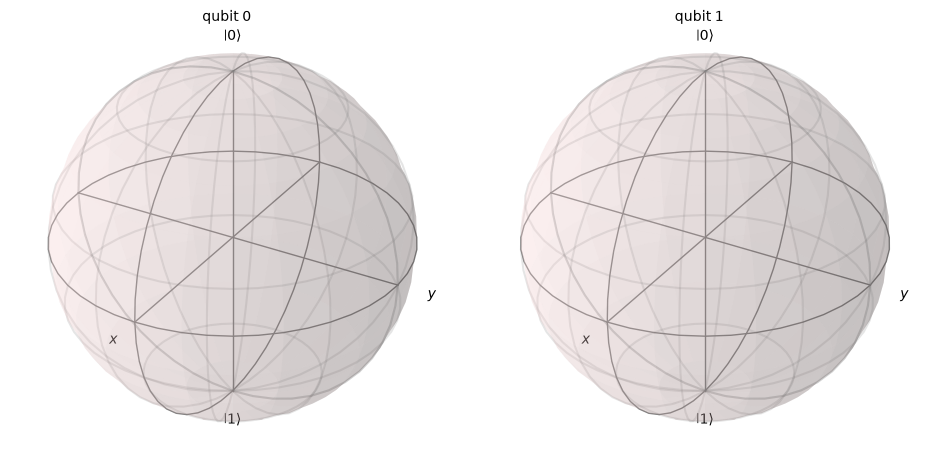

In [8]:
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)
print(qc_bell.draw())

state_bell = Statevector.from_instruction(qc_bell)
print("Statevector:", state_bell)
print("Is this a product state? No, this is the maximally entangled Bell state from Lecture 8.")
plot_bloch_multivector(state_bell)

Notice both Bloch vectors above sit at the centre of their spheres. That is not a mistake, it is the signature of entanglement: neither qubit has a well defined direction on its own, only the pair together has a well defined state.


> **In-class task 1.** Build a circuit that prepares $|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$, which is `h` followed by `z`, or equivalently an `x` followed by `h`. Print the statevector and plot its Bloch sphere. Where does $|-\rangle$ sit on the sphere compared to $|+\rangle$?


In [9]:
# TODO: build the |-> state and plot it


> ### Explore Further: Gates and the Bloch Sphere
>
> - **[Qiskit textbook: Single Qubit Gates](https://qiskit.qotlabs.org/docs/guides/construct-circuits)** Interactive treatment of every gate used above, with more Bloch sphere pictures.
> - **[Qiskit documentation: quantum_info.Statevector](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.Statevector)** The class used above to inspect any circuit's output state directly.


---
# Part 2: The Adiabatic Theorem in Action

Recall from Lecture 9 that the time-dependent Hamiltonian interpolates between a "mixer" Hamiltonian $H_M$ and a "problem" Hamiltonian $H_P$:

$$
H(t) = \big(1 - s(t)\big) H_M + s(t) H_P,
$$

with the linear schedule

$$
s(t) = \frac{t}{T}.
$$

We start in the easy ground state of $H_M$, evolve slowly, and aim to end in the ground state of $H_P$, which encodes the solution to the Max-Cut problem.

For this example, we use a 4-vertex graph with 5 edges:

$$
E = \{(0,1),\ (1,2),\ (2,3),\ (3,0),\ (0,2)\}.
$$

The graph is a 4-cycle plus one diagonal.



## 2.0 The Max-Cut Instance

We first build and visualize the graph.


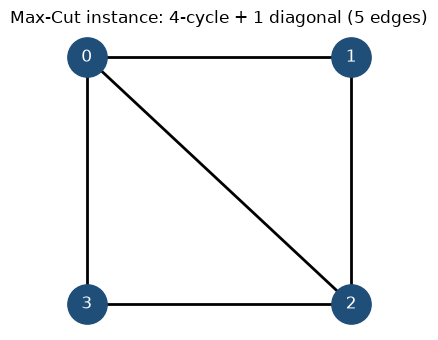

Nodes: [0, 1, 2, 3]
Edges: [(0, 1), (0, 3), (0, 2), (1, 2), (2, 3)]
|V| = 4, |E| = 5


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.linalg import eigh, expm


# ------------------------------------------------------------
# Build the 4-vertex, 5-edge Max-Cut graph
# ------------------------------------------------------------

G = nx.Graph()

G.add_nodes_from([0, 1, 2, 3])

G.add_edges_from([
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 0),
    (0, 2)
])

pos = {
    0: (0, 1),
    1: (1, 1),
    2: (1, 0),
    3: (0, 0)
}

fig, ax = plt.subplots(figsize=(3.5, 3.5))

nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=True,
    node_color="#1f4e79",
    font_color="white",
    node_size=800,
    width=2
)

ax.set_title("Max-Cut instance: 4-cycle + 1 diagonal (5 edges)")

plt.tight_layout()
plt.show()

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))
print(f"|V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}")

## 2.1 Building $H_M$ and $H_P$ as Matrices

For Max-Cut, each computational-basis state represents an assignment of every vertex to one of two partitions.

For example, $|0101\rangle$ means:

| Vertex    | 0 | 1 | 2 | 3 |
|-----------|---|---|---|---|
| Partition | 0 | 1 | 0 | 1 |

For an edge $(i,j)$, the quantity

$$
\frac{I - Z_i Z_j}{2}
$$

is equal to $1$ when the two vertices are placed in different partitions, and $0$ when they are placed in the same partition.

Therefore the total cut value is

$$
C(z) = \sum_{(i,j)\in E} \frac{I - Z_i Z_j}{2}.
$$

Because the adiabatic algorithm finds the **lowest**-energy state, we use

$$
\boxed{H_P = -C(z)}
$$

so that maximizing the cut becomes minimizing the energy.

We also add a small symmetry-breaking term $-0.15\,Z_0$ to make the ground state non-degenerate. Thus,

$$
\boxed{
H_P = -\sum_{(i,j)\in E} \frac{I - Z_i Z_j}{2} \;-\; 0.15\,Z_0.
}
$$

For the initial Hamiltonian, we use

$$
\boxed{H_M = -\sum_i X_i.}
$$

Its ground state is

$$
|{+}\rangle^{\otimes 4},
$$

which is the uniform superposition of all $2^4 = 16$ possible bit strings, and can be prepared using four Hadamard gates.

For our 5 edges, the problem Hamiltonian is explicitly

$$
\begin{aligned}
H_P ={}& -\frac{I - Z_0 Z_1}{2} - \frac{I - Z_1 Z_2}{2} - \frac{I - Z_2 Z_3}{2} \\[4pt]
       & - \frac{I - Z_3 Z_0}{2} - \frac{I - Z_0 Z_2}{2} - 0.15\,Z_0.
\end{aligned}
$$

So every graph edge contributes one term.

In [11]:
# ------------------------------------------------------------
# 2.1 Build the Hamiltonians
# ------------------------------------------------------------

I2 = np.eye(2)

X = np.array([
    [0, 1],
    [1, 0]
])

Z = np.array([
    [1, 0],
    [0, -1]
])


# Number of qubits = number of graph vertices
n_qubits = G.number_of_nodes()


def kron_list(ops):
    # Kronecker product of a list of matrices.
    result = ops[0]

    for op in ops[1:]:
        result = np.kron(result, op)

    return result


def single_qubit_operator(op, qubit, n=n_qubits):
    # Place a single-qubit operator on the selected qubit
    # and identity operators on all other qubits.
    ops = [I2] * n
    ops[qubit] = op
    return kron_list(ops)


# Identity on the full 4-qubit Hilbert space
I_full = np.eye(2 ** n_qubits)


# ------------------------------------------------------------
# Build H_M
#
# H_M = -(X_0 + X_1 + X_2 + X_3)
# ------------------------------------------------------------

H_M = np.zeros((2 ** n_qubits, 2 ** n_qubits))

for i in range(n_qubits):
    H_M -= single_qubit_operator(X, i)


# ------------------------------------------------------------
# Build H_P
#
# H_P = - sum_edges [(I - Z_i Z_j)/2] - 0.15 Z_0
# ------------------------------------------------------------

H_P = np.zeros((2 ** n_qubits, 2 ** n_qubits))

for i, j in G.edges():

    ZiZj = (
        single_qubit_operator(Z, i)
        @ single_qubit_operator(Z, j)
    )

    edge_cost = (I_full - ZiZj) / 2

    H_P -= edge_cost


# Small symmetry-breaking term
symmetry_breaking = 0.15

H_P -= symmetry_breaking * single_qubit_operator(Z, 0)


# ------------------------------------------------------------
# Print Hamiltonian information
# ------------------------------------------------------------

print("Number of qubits:", n_qubits)
print("Hilbert-space dimension:", 2 ** n_qubits)

print("\nH_M eigenvalues:")
print(np.round(eigh(H_M, eigvals_only=True), 3))

print("\nH_P eigenvalues:")
print(np.round(eigh(H_P, eigvals_only=True), 3))

Number of qubits: 4
Hilbert-space dimension: 16

H_M eigenvalues:
[-4. -2. -2. -2. -2. -0. -0.  0.  0.  0.  0.  2.  2.  2.  2.  4.]

H_P eigenvalues:
[-4.15 -3.85 -3.15 -3.15 -3.15 -3.15 -2.85 -2.85 -2.85 -2.85 -2.15 -2.15
 -1.85 -1.85 -0.15  0.15]


This is the adiabatic theorem, made visible. Rush the evolution and the state gets left behind in the wrong energy level. Slow it down enough, past the point set by the minimum spectral gap, and the state faithfully rides the ground state all the way to the answer.


## 2.2 Simulating the Evolution for a Chosen Schedule and Total Time $T$

We discretize the evolution into small time steps. At each step,

$$
H(t) = \big(1 - s(t)\big) H_M + s(t) H_P.
$$

The corresponding short-time evolution operator is

$$
U(t) = e^{-i H(t)\, \Delta t}.
$$

We repeatedly apply this unitary to the quantum state. The initial state is the ground state of $H_M$. We then monitor the probability of being in the ground state of $H_P$.

### Postulate 2: Time Evolution

The evolution of a closed quantum system is governed by the **Schrödinger equation**.  
If the system is in state $|\psi(t)\rangle$ at time $t$, then its time evolution is given by:

$$
|\psi(t)\rangle = U(t) |\psi(0)\rangle,
$$

where the unitary operator $U(t)$ is

$$
U(t) = e^{-iHt}.
$$

Here, $H$ is the Hamiltonian of the system, which encodes its energy and dynamics.


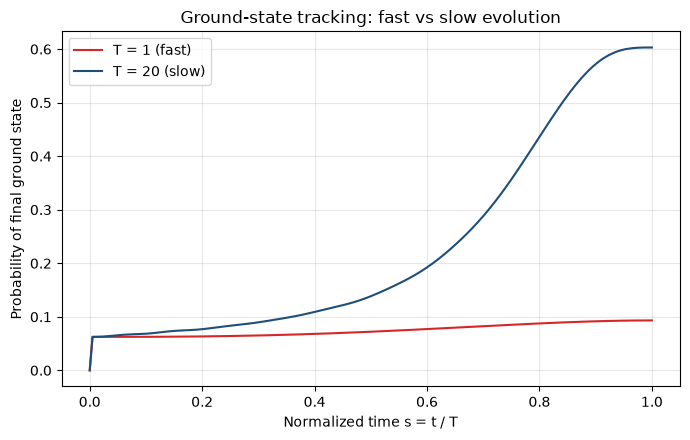

Final success probability, T=1:  0.093
Final success probability, T=20: 0.603


In [12]:
# ------------------------------------------------------------
# 2.2 Adiabatic evolution
# ------------------------------------------------------------

def ground_state(H):
    # Return the ground-state eigenvector and ground-state energy.
    eigvals, eigvecs = eigh(H)

    return eigvecs[:, 0], eigvals[0]


def linear_schedule(t, T):
    # Linear schedule: s(t) = t / T
    return t / T


def quadratic_schedule(t, T):
    # Quadratic schedule: s(t) = (t / T)^2
    return (t / T) ** 2


def run_adiabatic_evolution(
    H_M,
    H_P,
    T,
    schedule_fn,
    n_steps=200
):
    # Simulate adiabatic evolution from H_M to H_P.
    # The evolution is divided into n_steps.

    # Initial state = ground state of H_M
    psi, initial_energy = ground_state(H_M)

    psi = psi.astype(complex)

    # Ground state of the final problem Hamiltonian
    problem_ground_state, problem_ground_energy = ground_state(H_P)

    # Time discretization
    dt = T / n_steps

    times = np.linspace(0, T, n_steps + 1)

    success_probs = [0.0]

    # Evolve through each time interval
    for k in range(n_steps):

        # Use midpoint of the interval
        t_mid = (times[k] + times[k + 1]) / 2

        s = schedule_fn(t_mid, T)

        # Interpolated Hamiltonian
        H_t = (1 - s) * H_M + s * H_P

        # Short-time unitary
        U = expm(-1j * H_t * dt)

        # Evolve state
        psi = U @ psi

        # Probability of being in final ground state
        overlap = abs(np.vdot(problem_ground_state, psi)) ** 2

        success_probs.append(overlap)

    return times, np.array(success_probs)


# ------------------------------------------------------------
# Compare fast and slow evolution
# ------------------------------------------------------------

times_fast, probs_fast = run_adiabatic_evolution(
    H_M,
    H_P,
    T=1.0,
    schedule_fn=linear_schedule
)

times_slow, probs_slow = run_adiabatic_evolution(
    H_M,
    H_P,
    T=20.0,
    schedule_fn=linear_schedule
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    times_fast / times_fast[-1],
    probs_fast,
    label="T = 1 (fast)",
    color="#d62728"
)

ax.plot(
    times_slow / times_slow[-1],
    probs_slow,
    label="T = 20 (slow)",
    color="#1f4e79"
)

ax.set_xlabel("Normalized time s = t / T")

ax.set_ylabel(
    "Probability of final ground state"
)

ax.set_title(
    "Ground-state tracking: fast vs slow evolution"
)

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(
    f"Final success probability, T=1:  "
    f"{probs_fast[-1]:.3f}"
)

print(
    f"Final success probability, T=20: "
    f"{probs_slow[-1]:.3f}"
)

### The important idea is:

$$
\boxed{H_M \longrightarrow H_P}
$$

rather than trying to solve $H_P$ immediately.

- For small $T$, the Hamiltonian changes quickly and the state may not remain in the instantaneous ground state.
- For sufficiently large $T$, the evolution becomes more adiabatic and the state can track the ground state.

## 2.3 The Energy Gap Along the Path

The relevant gap is

$$
\boxed{\Delta(s) = E_1(s) - E_0(s)}
$$

where:
- $E_0$ = lowest energy
- $E_1$ = second-lowest energy

The minimum value

$$
\Delta_{\min} = \min_s \Delta(s)
$$

is especially important for adiabatic evolution.

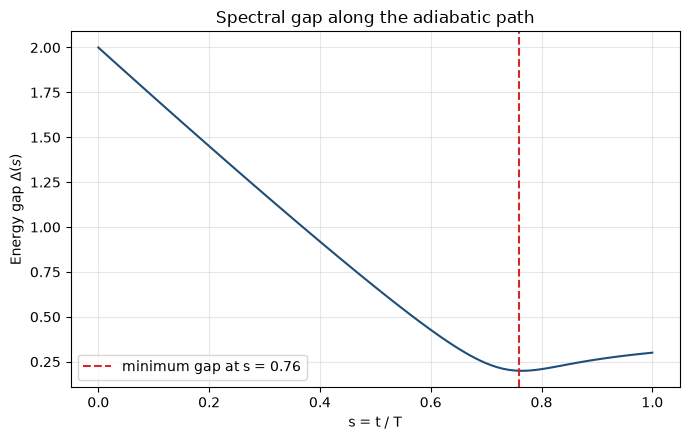

Minimum gap: 0.199 at s = 0.76


In [13]:
# ------------------------------------------------------------
# 2.3 Energy gap along the adiabatic path
# ------------------------------------------------------------

s_values = np.linspace(0, 1, 101)

gaps = []

for s in s_values:

    H_s = (1 - s) * H_M + s * H_P

    eigvals = eigh(
        H_s,
        eigvals_only=True
    )

    gap = eigvals[1] - eigvals[0]

    gaps.append(gap)


gaps = np.array(gaps)

min_gap = gaps.min()

s_star = s_values[np.argmin(gaps)]


# ------------------------------------------------------------
# Plot the gap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    s_values,
    gaps,
    color="#1f4e79"
)

ax.axvline(
    s_star,
    color="#d62728",
    linestyle="--",
    label=f"minimum gap at s = {s_star:.2f}"
)

ax.set_xlabel("s = t / T")

ax.set_ylabel(
    r"Energy gap $\Delta(s)$"
)

ax.set_title(
    "Spectral gap along the adiabatic path"
)

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(
    f"Minimum gap: {min_gap:.3f} "
    f"at s = {s_star:.2f}"
)

> **In-class task 2.** In section 2.2, try `T = 3` and `T = 50` (keep `linear_schedule`). At what rough value of `T` does the final success probability cross above 0.9? Relate this back to the minimum gap you just plotted: the adiabatic theorem says the required $T$ scales as $1/\Delta_{\min}^2$.

> **In-class task 3.** Re-run section 2.2 using `schedule_fn=quadratic_schedule` for both `T=1` and `T=20`. A quadratic schedule spends *less* time near $s=0$ and *more* time near $s=1$, which is the opposite of what you usually want when the minimum gap sits in the middle of the path. Does the quadratic schedule do better or worse than the linear one at the same $T$?


In [14]:
# TODO: in-class task 2 and 3


> ### Explore Further: Adiabatic Evolution
>
> - **[Albash & Lidar, "Adiabatic Quantum Computation," Rev. Mod. Phys. 90, 015002 (2018)](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.90.015002)** The full theorem with rigorous conditions, referenced on slide 13 of Lecture 8.
> - **[D-Wave Documentation: Annealing Schedules](https://docs.dwavequantum.com/en/latest/quantum_research/annealing.html)** How real annealers let you pause or reshape $s(t)$ near a small gap.


---
# Part 3: Trotterizing the evolution into gates
A real gate based device cannot apply $e^{-iH(t)t}$ directly for a continuously changing $H(t)$. Instead it chops evolution into $p$ short steps and alternates short pulses of $H_M$ and $H_P$, using the Trotter-Suzuki formula from Lecture 8, slide 17:

$$e^{-i(A+B)\Delta t} \approx e^{-iA\Delta t}e^{-iB\Delta t}$$

For our Max-Cut example, one Trotter step looks like: a $ZZ$ rotation for the $H_P$ term, then an $X$ rotation on each qubit for the $H_M$ term. This alternating structure is exactly the QAOA circuit you will build in the next lab, it is nothing but a fixed-depth Trotterization of what we just simulated.


### General QAOA Ansatz

The full QAOA state after \(p\) layers is:

$$
|\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle 
= \prod_{k=1}^{p} e^{-i\beta_k H_M} \, e^{-i\gamma_k H_P} \, |+\rangle^{\otimes n}.
$$

- The initial state $|+\rangle^{\otimes n}$ is prepared by Hadamard gates.  
- Each layer applies the problem unitary $e^{-i\gamma_k H_P}$ followed by the mixer unitary $e^{-i\beta_k H_M}$.  
- The parameters $\gamma_k, \beta_k$ are optimized to maximize the expected objective value.


![](Totterization.png)

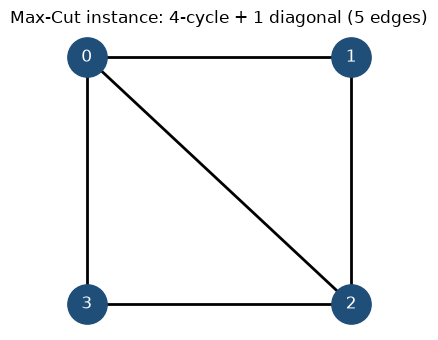

Nodes: [0, 1, 2, 3]
Edges: [(0, 1), (0, 3), (0, 2), (1, 2), (2, 3)]
|V| = 4, |E| = 5


In [15]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3])
G.add_edges_from([
    (0, 1), (1, 2), (2, 3), (3, 0),   # the 4-cycle
    (0, 2)                             # diagonal joining opposite vertices
])

pos = {0: (0, 1), 1: (1, 1), 2: (1, 0), 3: (0, 0)}  # square layout

fig, ax = plt.subplots(figsize=(3.5, 3.5))
nx.draw(
    G, pos, ax=ax, with_labels=True,
    node_color="#1f4e79", font_color="white",
    node_size=800, width=2
)
ax.set_title("Max-Cut instance: 4-cycle + 1 diagonal (5 edges)")
plt.tight_layout()
plt.show()

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))
print(f"|V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}")

In [16]:
n = G.number_of_nodes()

def kron_list(ops):
    result = ops[0]
    for op in ops[1:]:
        result = np.kron(result, op)
    return result

def single_qubit_op(op, qubit, n):
    ops = [I2] * n
    ops[qubit] = op
    return kron_list(ops)

def two_qubit_ZZ(q0, q1, n):
    ops = [I2] * n
    ops[q0] = Z
    ops[q1] = Z
    return kron_list(ops)

dim = 2 ** n
H_P = np.zeros((dim, dim))
for (i, j) in G.edges():
    H_P += (np.eye(dim) - two_qubit_ZZ(i, j, n)) / 2

# small symmetry-breaking term to avoid a fully degenerate ground state
H_P = H_P - 0.15 * single_qubit_op(Z, 0, n)

H_M = np.zeros((dim, dim))
for q in range(n):
    H_M -= single_qubit_op(X, q, n)

print("H_P eigenvalues (lowest few):", np.round(eigh(H_P, eigvals_only=True)[:4], 3))
print("H_M eigenvalues (lowest few):", np.round(eigh(H_M, eigvals_only=True)[:4], 3))

H_P eigenvalues (lowest few): [-0.15  0.15  1.85  1.85]
H_M eigenvalues (lowest few): [-4. -2. -2. -2.]


In [17]:
def trotter_circuit(p_steps, gamma, beta, graph):
    n = graph.number_of_nodes()
    qc = QuantumCircuit(n)
    qc.h(range(n))  # start in the ground state of H_M

    for _ in range(p_steps):
        # problem unitary e^{-i gamma H_P}: one RZZ per edge
        for (i, j) in graph.edges():
            qc.rzz(2 * gamma, i, j)
        # mixer unitary e^{-i beta H_M}: one RX per qubit
        for q in range(n):
            qc.rx(2 * beta, q)

    return qc

qc_trotter = trotter_circuit(p_steps=3, gamma=0.8, beta=0.3, graph=G)
print(qc_trotter.draw())

state_trotter = Statevector.from_instruction(qc_trotter)
probs_trotter = state_trotter.probabilities_dict()
print("\nOutcome probabilities:")
for bitstring, p in sorted(probs_trotter.items(), key=lambda x: -x[1]):
    print(f"  |{bitstring}>: {p:.3f}")

     ┌───┐                              ┌─────────┐                      »
q_0: ┤ H ├─■─────────■─────────■────────┤ Rx(0.6) ├─────────────■────────»
     ├───┤ │ZZ(1.6)  │         │        └─────────┘┌─────────┐  │ZZ(1.6) »
q_1: ┤ H ├─■─────────┼─────────┼──────────■────────┤ Rx(0.6) ├──■────────»
     ├───┤           │         │ZZ(1.6)   │ZZ(1.6) └─────────┘┌─────────┐»
q_2: ┤ H ├───────────┼─────────■──────────■──────────■────────┤ Rx(0.6) ├»
     ├───┤           │ZZ(1.6)                        │ZZ(1.6) ├─────────┤»
q_3: ┤ H ├───────────■───────────────────────────────■────────┤ Rx(0.6) ├»
     └───┘                                                    └─────────┘»
«                         ┌─────────┐                                          »
«q_0: ─■─────────■────────┤ Rx(0.6) ├─────────────■─────────■─────────■────────»
«      │         │        └─────────┘┌─────────┐  │ZZ(1.6)  │         │        »
«q_1: ─┼─────────┼──────────■────────┤ Rx(0.6) ├──■─────────┼─────────┼────────»
«

In [18]:
best_cut, best_bits = -1, None
for bits in itertools.product([0, 1], repeat=n):
    cut = sum(1 for (i, j) in G.edges() if bits[i] != bits[j])
    if cut > best_cut:
        best_cut, best_bits = cut, bits
print(f"Best cut: {best_cut} edges, achieved by {best_bits}")

Best cut: 4 edges, achieved by (0, 1, 0, 1)


Optimal cut value: 4 edges
Optimal bitstrings: ['1010', '0101']


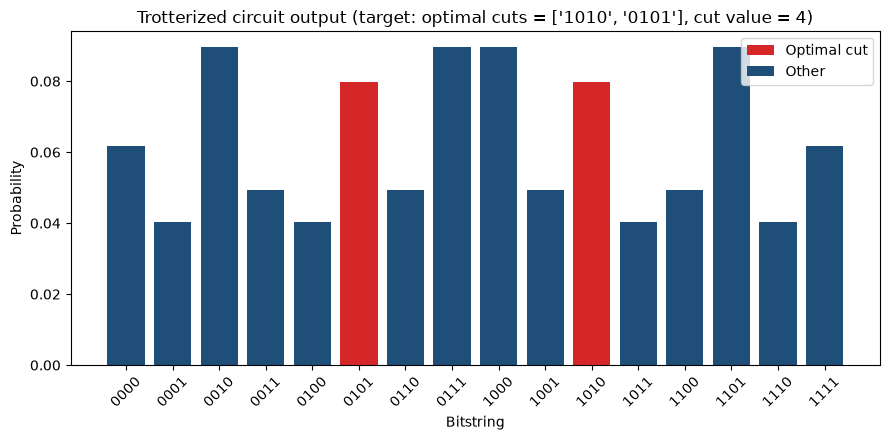

In [19]:
# Get the optimal cut bitstrings via brute force (as computed earlier)
best_cut, best_bitstrings = -1, []
for bits in itertools.product([0, 1], repeat=n):
    cut = sum(1 for (i, j) in G.edges() if bits[i] != bits[j])
    if cut > best_cut:
        best_cut, best_bitstrings = cut, [bits]
    elif cut == best_cut:
        best_bitstrings.append(bits)

# Convert tuples like (0,1,0,1) to bitstrings like "0101" matching Qiskit's ordering
# Qiskit's bitstrings are little-endian (qubit 0 is the rightmost character)
optimal_strs = ["".join(str(b) for b in bits[::-1]) for bits in best_bitstrings]
print(f"Optimal cut value: {best_cut} edges")
print(f"Optimal bitstrings: {optimal_strs}")

fig, ax = plt.subplots(figsize=(9, 4.5))
bitstrings = sorted(probs_trotter.keys())
colors = ["#d62728" if b in optimal_strs else "#1f4e79" for b in bitstrings]

ax.bar(bitstrings, [probs_trotter[b] for b in bitstrings], color=colors)
ax.set_ylabel("Probability")
ax.set_xlabel("Bitstring")
ax.set_title(f"Trotterized circuit output (target: optimal cuts = {optimal_strs}, cut value = {best_cut})")
ax.tick_params(axis='x', rotation=45)

# simple legend
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#d62728", label="Optimal cut"),
    Patch(facecolor="#1f4e79", label="Other")
]
ax.legend(handles=legend_elems)

plt.tight_layout()
plt.show()

> **In-class task 4.** Change `p_steps` in the cell above from 3 to 1, then to 10, keeping `gamma=0.8, beta=0.3`. Does more Trotter steps push more probability onto the correct answers? This single parameter, the circuit depth, is the main knob you will tune for QAOA in the next lab.


In [20]:
# TODO: in-class task 4


> ### Explore Further: Trotterization and QAOA
>
> - **[Farhi, Goldstone, Gutmann, "A Quantum Approximate Optimization Algorithm," 2014 (arXiv:1411.4028)](https://arxiv.org/abs/1411.4028)** The original QAOA paper, built exactly on the Trotterization idea above.
> - **[Qiskit tutorial: QAOA](https://qiskit-community.github.io/qiskit-optimization/tutorials/index.html)** Where the circuit you just wrote by hand is packaged into a reusable class, next lab.


---
# Part 4: Solving SAT with a quantum annealing style QUBO

Boolean satisfiability, SAT, asks whether some assignment of `True` and `False` to a set of variables makes every clause in a formula `True`. 2-SAT is solvable in polynomial time, but 3-SAT is the textbook NP-complete problem: every NP problem can be reduced to it. It is exactly the kind of problem the ground state of a problem Hamiltonian $H_P$ is meant to encode.

We do not have quantum annealing hardware, so `dwave-neal`'s classical simulated annealer stands in for it here, the same substitution we used for Max-Cut, Vertex Cover, and Graph Coloring in earlier labs, and the same idea a real D-Wave device implements continuously as described in Lecture 8, slide 19.


## 4.1 A small 2-SAT instance

Each clause is a list of literals, a positive integer $i$ means variable $x_i$, a negative integer $-i$ means $\neg x_i$. A clause $(x_0 \lor \lnot x_1)$ is written `[1, -2]` below using 1-indexed variables for readability.


In [ ]:
def clause_satisfied(clause, assignment):
    for lit in clause:
        var = abs(lit) - 1
        value = assignment[var]
        if lit > 0 and value == 1:
            return True
        if lit < 0 and value == 0:
            return True
    return False

def all_satisfied(clauses, assignment):
    return all(clause_satisfied(c, assignment) for c in clauses)

# (x1 OR x2) AND (NOT x1 OR x3) AND (NOT x2 OR NOT x3)
clauses_2sat = [[1, 2], [-1, 3], [-2, -3]]
n_vars_2sat = 3

for assignment in itertools.product([0, 1], repeat=n_vars_2sat):
    if all_satisfied(clauses_2sat, assignment):
        print("A satisfying assignment (brute force):", assignment)
        break

## 4.2 Turning SAT clauses into a QUBO

For each clause, define its "unsatisfied indicator" as the product of each literal's negation. For a 2-literal clause $(x_i \lor \lnot x_j)$, that is $(1-x_i)\, x_j$, exactly the same style of penalty term used for Minimum Vertex Cover in Lab 2. We want to minimize the number of unsatisfied clauses, so we sum these indicator terms and hand the whole thing to `dimod`.

Longer clauses (3-SAT) give cubic terms, which a QUBO cannot represent directly since QUBOs are only quadratic. `dimod.make_quadratic` automatically introduces extra ancilla variables to reduce a higher order term to a quadratic one, the same trick a real quantum annealer's embedding has to perform.


In [ ]:
def sat_objective(clauses, n_vars):
    '''Builds a BinaryPolynomial: one term per clause, equal to 1 exactly when that clause is violated.'''
    poly = {}
    for clause in clauses:
        term_vars = []
        for lit in clause:
            var = abs(lit) - 1
            if lit > 0:
                # (1 - x_i) contributes to "literal is false"
                term_vars.append(("neg", var))
            else:
                # x_i contributes to "literal is false" when the literal is NOT x_i
                term_vars.append(("pos", var))

        # multiply out the "all literals false" product, add each resulting monomial
        def expand(vars_left, current_key, sign):
            if not vars_left:
                poly[current_key] = poly.get(current_key, 0) + sign
                return
            kind, var = vars_left[0]
            rest = vars_left[1:]
            if kind == "neg":
                # (1 - x_i) = 1 - x_i
                expand(rest, current_key, sign)
                expand(rest, tuple(sorted(current_key + (var,))), -sign)
            else:
                # x_i
                expand(rest, tuple(sorted(current_key + (var,))), sign)

        expand(term_vars, tuple(), 1)

    poly.pop(tuple(), None)  # drop constant term, does not affect the minimizer
    return {k: v for k, v in poly.items() if v != 0}

def solve_sat_with_annealing(clauses, n_vars, num_reads=200):
    poly = sat_objective(clauses, n_vars)
    bqm = dimod.make_quadratic(poly, strength=5.0, vartype=dimod.BINARY)
    result = sampler.sample(bqm, num_reads=num_reads, num_sweeps=1000)
    best = result.first.sample
    assignment = tuple(best[i] for i in range(n_vars))
    return assignment, result.first.energy

assignment_2sat, energy_2sat = solve_sat_with_annealing(clauses_2sat, n_vars_2sat)
print("QUBO/annealing solution:", assignment_2sat)
print("Energy (0 means every clause satisfied):", energy_2sat)
print("All clauses satisfied?", all_satisfied(clauses_2sat, assignment_2sat))

## 4.3 A 3-SAT instance

Same idea, longer clauses. `make_quadratic` will quietly add ancilla variables to handle the cubic terms, print the ancilla count to see this happening.


In [ ]:
# (x1 OR x2 OR x3) AND (NOT x1 OR NOT x2 OR x4) AND (x2 OR NOT x3 OR NOT x4) AND (NOT x1 OR x3 OR x4)
clauses_3sat = [[1, 2, 3], [-1, -2, 4], [2, -3, -4], [-1, 3, 4]]
n_vars_3sat = 4

poly_3sat = sat_objective(clauses_3sat, n_vars_3sat)
bqm_3sat = dimod.make_quadratic(poly_3sat, strength=5.0, vartype=dimod.BINARY)
print(f"Original variables: {n_vars_3sat}")
print(f"Variables after reduction to quadratic (includes ancillas): {len(bqm_3sat.variables)}")

result_3sat = sampler.sample(bqm_3sat, num_reads=300, num_sweeps=1000)
best_3sat = result_3sat.first.sample
assignment_3sat = tuple(best_3sat[i] for i in range(n_vars_3sat))

print("\nQUBO/annealing solution:", assignment_3sat)
print("Energy (0 means every clause satisfied):", result_3sat.first.energy)
print("All clauses satisfied?", all_satisfied(clauses_3sat, assignment_3sat))

for assignment in itertools.product([0, 1], repeat=n_vars_3sat):
    if all_satisfied(clauses_3sat, assignment):
        print("A satisfying assignment (brute force check):", assignment)
        break

> **In-class task 5.** Add a fifth clause `[-2, -4]` (meaning $\lnot x_2 \lor \lnot x_4$) to a copy of `clauses_3sat` and rerun 4.3. First check by brute force whether the new formula is still satisfiable. Then rerun the annealer. If the formula became unsatisfiable, does the annealer's best energy still reach 0? What does a nonzero minimum energy tell you about a formula, without needing to brute force it yourself?


In [ ]:
# TODO: in-class task 5


> ### Explore Further: SAT, QUBO and Quantum Annealing
>
> - **[Lucas, "Ising formulations of many NP problems," 2014 (arXiv:1302.5843)](https://arxiv.org/abs/1302.5843)** Section 4.5 gives the SAT to Ising mapping directly.
> - **[D-Wave Examples: Boolean SAT](https://github.com/dwave-examples)** Worked SAT to QUBO examples on real hardware.
> - **[dimod documentation: make_quadratic](https://docs.ocean.dwavesys.com/en/stable/docs_dimod/reference/higherorder.html)** How higher order penalty terms get reduced with ancilla variables, the same idea behind minor embedding on real annealer hardware.


---
# Lab summary

| Part | What we did | Where it goes next |
|---|---|---|
| 1. Gates and Bloch sphere | Built `H`, `RX`, `RY`, `CNOT` circuits, read statevectors and Bloch plots | Every parameterized circuit in QAOA, VQE, VQC uses exactly these gates |
| 2. Adiabatic evolution | Simulated $H(t)=(1-s)H_M+sH_P$, compared fast vs slow, linear vs quadratic schedules | The adiabatic theorem is the physical justification for why quantum annealing and QAOA should work at all |
| 3. Trotterization | Alternated $e^{-i\gamma H_P}$ and $e^{-i\beta H_M}$ into a fixed-depth circuit | This alternating structure *is* the QAOA ansatz, next lab |
| 4. SAT as a QUBO | Reduced 2-SAT and 3-SAT clauses to a QUBO with `dimod.make_quadratic`, solved with simulated annealing | Same recipe you will reuse to define a cost Hamiltonian for QAOA/VQE on any NP-hard problem |

**Next lab:** Variational Quantum Algorithms, QAOA, VQE, and VQC. You already have every piece: the gates from Part 1, the cost Hamiltonian construction from Part 4, and the alternating mixer/problem structure from Part 3. QAOA simply lets a classical optimizer choose $\gamma$ and $\beta$ instead of us guessing them.


---
# Part 5: Exercises

Complete these after the live session, on your own. None of them require writing a new algorithm from scratch, only changing a parameter or a few lines in cells you already ran. Re-run the relevant cells after each change and record what you observe, in your own words and your own numbers.

Do not use an AI tool to write or check your answers for these exercises. The point is for you to build the intuition yourself, working through it with an assistant defeats that purpose, and the answers below can only be verified by you actually running the code and reading the plots.

**Exercise 1 (Gates, easy).** In section 1.3, generate the Bloch sphere for `RY` at five angles of your choice between $0$ and $2\pi$. At what angle does the Bloch vector point straight down, i.e. the state becomes $|1\rangle$? Explain why in one sentence using the formula $|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$ from Lecture 8.

**Exercise 2 (Adiabatic theorem, medium).** In section 2.1, `H_P` sums an edge-cost term $(I - Z_iZ_j)/2$ over every edge of the 4-vertex graph `G`. Pick one edge, say `(0, 1)`, and weaken only its contribution by multiplying that one term by $0.05$ before subtracting it in (so that edge barely affects the cost anymore, while the other four edges stay full strength). Rebuild `H_P` and replot the energy gap from section 2.3. What happens to the minimum gap compared to the original `H_P`, and based on section 2.2, what does that predict about how large `T` needs to be for a successful adiabatic run? Verify by running section 2.2 again with the new `H_P`.

**Exercise 3 (Adiabatic theorem, medium).** Write a `cosine_schedule(t, T)` function using $s(t) = \frac{1 - \cos(\pi t / T)}{2}$ you can use this formula for cosine schedule: $s(t) = (1 - cos(pi * t / T)) / 2$, which moves slowly near $s=0$ and $s=1$ and quickly through the middle. Run it through section 2.2 at $T=20$ (with the original `H_P`) and compare its final success probability against the linear and quadratic schedules at the same $T$. Which schedule wins, and does that match what section 2.3's gap plot would predict about where slowing down helps most?

**Exercise 4 (Trotterization, easy).** In section 3, try three different `(gamma, beta)` pairs at `p_steps=5`, for example `(0.4, 0.2)`, `(0.8, 0.3)`, and `(1.2, 0.5)`. Which pair puts the most probability on the optimal Max-Cut bitstrings for graph `G`? This is exactly the parameter search a classical optimizer performs inside QAOA, next lab.

**Exercise 5 (SAT, medium).** Build your own 3-SAT instance with 5 variables and 5 clauses of your choosing. First check satisfiability by brute force, then solve it with `solve_sat_with_annealing`. Report the number of ancilla variables `make_quadratic` introduced (the difference between `n_vars` and the number of variables in the resulting BQM) and the final energy.

**Exercise 6 (SAT, hard, optional).** A formula built entirely from clauses like `[-1, -2, -3]` is satisfied by many assignments, since the all-zeros assignment trivially satisfies every clause that has at least one negative literal. Construct a 3-SAT formula on 4 variables that has exactly one satisfying assignment (verify with brute force), then confirm the annealer, run in the style of section 4.3, finds that exact assignment across several reruns. What does this tell you about a `strength` value in `make_quadratic` that is too small?

## What to submit

Save this notebook with all cells executed and their output, plots, and circuit diagrams visible, along with your answers to the six exercises above (a few sentences each, plus the specific numbers or plots you observed where asked). If you explored beyond what the exercises ask, leave a short note describing what you changed and what effect it had.
